# accelerations_per_min — Model Notebook

Response: `accelerations_per_min` — total acceleration *and* deceleration
threshold crossings (any rising edge above `ACCEL_THRESH` mph/s) per minute.

This is a noisier metric than `acceleration_events_per_min` (sustained bouts)
because it counts every brief spike. The same Poisson / NegBin / OLS
comparison applies, using `accel_count` as the raw count response.


In [1]:
import sys, warnings
sys.path.insert(0, str(__import__('pathlib').Path('.').resolve()))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

from build_shift_df import (
    build_shift_df,
    PREDICTORS,
    POS_COLORS,
    FPS,
    ACCEL_THRESH,
    SUSTAINED_FRAMES,
)

OUTPUT_DIR = __import__('pathlib').Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

shift_df = build_shift_df('../data', force=True)

# Derived model columns shared by all notebooks
shift_df['is_first_int']       = shift_df['is_first_shift'].astype(int)
shift_df['rest_time_min']      = shift_df['rest_time_s'] / 60.0
shift_df['shift_duration_min'] = shift_df['shift_duration_s'] / 60.0

print(f'shift_df: {len(shift_df):,} shifts  |  columns: {list(shift_df.columns)}')


Building shift_df from scratch …
  Tracking rows : 8,401,602
  Speed present : True
  Skater shifts (P1–P3): 7,589
  Tracking groups: 981  |  accel_mph_s present: True
  Shifts with >=300 frames: 6,218
  Position labels joined: 6,218/6,218 (100.0%)
  Saved cache → /Users/joeharter/repos/bdc-2026/stamina_models/shift_df.parquet
  Final shape : (6218, 30)
shift_df: 6,218 shifts  |  columns: ['Game', 'Team', 'Period_int', 'Player_Id', 'shift_number', 'shift_start_s', 'shift_end_s', 'shift_duration_s', 'rest_time_s', 'is_first_shift', 'n_frames', 'ice_min', 'dist_ft', 'dist_ft_per_min', 'mean_abs_x', 'std_x', 'mean_abs_y', 'std_y', 'frac_deep_zone', 'speed_mean', 'accel_count', 'accelerations_per_min', 'accel_events_count', 'acceleration_events_per_min', 'mean_accel_magnitude', 'cumulative_ice_min_before', 'position', 'Home_Team_Goals', 'Away_Team_Goals', 'score_diff', 'is_first_int', 'rest_time_min', 'shift_duration_min']


In [2]:
shift_df['position'].value_counts()

position
D    3673
F    1754
C     791
Name: count, dtype: int64

## EDA

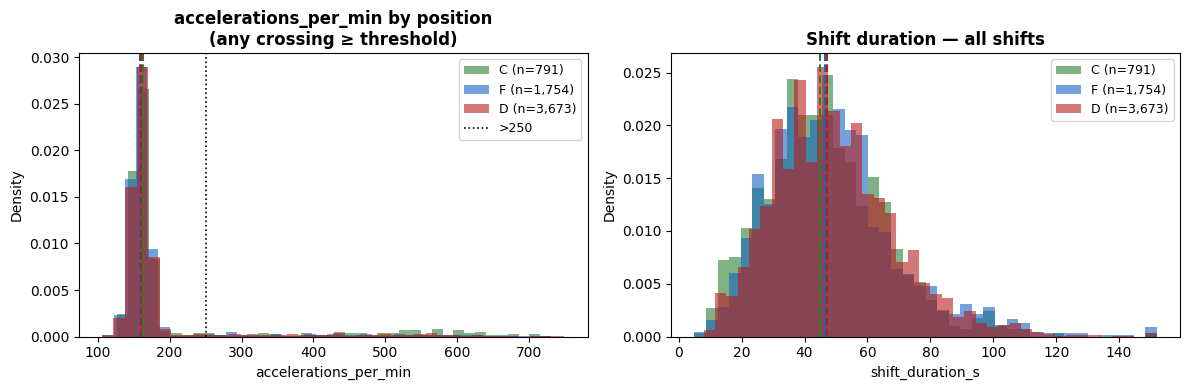

count    6218.00
mean      186.60
std        93.99
min       106.04
25%       152.60
50%       160.94
75%       170.04
max       748.56


In [3]:
ACCEL_HIGH_THRESH = 250

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for pos, col in POS_COLORS.items():
    vals = shift_df.loc[shift_df['position'] == pos, 'accelerations_per_min'].dropna()
    ax.hist(vals, bins=40, alpha=0.6, color=col, label=f'{pos} (n={len(vals):,})',
            density=True, edgecolor='none')
    ax.axvline(vals.median(), color=col, lw=1.5, ls='--')
ax.axvline(ACCEL_HIGH_THRESH, color='black', lw=1.2, ls=':', label=f'>{ACCEL_HIGH_THRESH}')
ax.set_xlabel('accelerations_per_min')
ax.set_ylabel('Density')
ax.set_title('accelerations_per_min by position\n(any crossing ≥ threshold)', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
for pos, col in POS_COLORS.items():
    vals = shift_df.loc[shift_df['position'] == pos, 'shift_duration_s'].dropna()
    ax.hist(vals, bins=40, alpha=0.6, color=col, label=f'{pos} (n={len(vals):,})',
            density=True, edgecolor='none')
    ax.axvline(vals.median(), color=col, lw=1.5, ls='--')
ax.set_xlabel('shift_duration_s')
ax.set_ylabel('Density')
ax.set_title('Shift duration — all shifts', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_eda_accels.png', dpi=150, bbox_inches='tight')
plt.show()

print(shift_df['accelerations_per_min'].describe().round(2).to_string())


## OLS Baseline

In [4]:
model_df = shift_df.dropna(subset=['accelerations_per_min', 'rest_time_s']).copy()

ols = smf.ols(f'accelerations_per_min ~ {PREDICTORS}', data=model_df).fit()
print(ols.summary2())
print(f'\nR² = {ols.rsquared:.4f}   adj-R² = {ols.rsquared_adj:.4f}   '
      f'RMSE = {np.sqrt(ols.mse_resid):.3f} crossings/min')


                          Results: Ordinary least squares
Model:                  OLS                       Adj. R-squared:         0.062     
Dependent Variable:     accelerations_per_min     AIC:                    73758.2536
Date:                   2026-03-14 22:20          BIC:                    73825.6056
No. Observations:       6218                      Log-Likelihood:         -36869.   
Df Model:               9                         F-statistic:            46.45     
Df Residuals:           6208                      Prob (F-statistic):     1.30e-81  
R-squared:              0.063                     Scale:                  8288.1    
------------------------------------------------------------------------------------
                                  Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
------------------------------------------------------------------------------------
Intercept                        160.2088   4.2151  38.0080 0.0000 151.9457 168.4720
C(posit

## GLM — Poisson with Exposure Offset

In [5]:
count_df = shift_df.dropna(subset=['accel_count', 'rest_time_s', 'ice_min']).copy()
count_df = count_df[count_df['ice_min'] > 0]
count_df['log_ice_min'] = np.log(count_df['ice_min'])

glm_poisson = smf.glm(
    f'accel_count ~ {PREDICTORS}',
    data=count_df,
    family=sm.families.Poisson(),
    offset=count_df['log_ice_min'],
).fit()

print(glm_poisson.summary2())

pearson_disp = glm_poisson.pearson_chi2 / glm_poisson.df_resid
print(f'\nPearson dispersion = {pearson_disp:.3f}')
print(f'AIC (Poisson) = {glm_poisson.aic:.1f}')


                        Results: Generalized linear model
Model:                    GLM                    AIC:                  204461.5589
Link Function:            Log                    BIC:                  110548.0225
Dependent Variable:       accel_count            Log-Likelihood:       -1.0222e+05
Date:                     2026-03-14 22:20       LL-Null:              -1.1241e+05
No. Observations:         6218                   Deviance:             1.6478e+05 
Df Model:                 9                      Pearson chi2:         2.16e+05   
Df Residuals:             6208                   Scale:                1.0000     
Method:                   IRLS                                                    
----------------------------------------------------------------------------------
                                  Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------------------
Intercept                    

## GLM — Negative Binomial

In [6]:
glm_nb = smf.glm(
    f'accel_count ~ {PREDICTORS}',
    data=count_df,
    family=sm.families.NegativeBinomial(),
    offset=count_df['log_ice_min'],
).fit()

print(glm_nb.summary2())
print(f'\nAIC (NegBin)  = {glm_nb.aic:.1f}')
print(f'AIC (Poisson) = {glm_poisson.aic:.1f}')
print(f'AIC (OLS)     = {ols.aic:.1f}')


                        Results: Generalized linear model
Model:                     GLM                   AIC:                 69730.5014 
Link Function:             Log                   BIC:                 -53481.2676
Dependent Variable:        accel_count           Log-Likelihood:      -34855.    
Date:                      2026-03-14 22:20      LL-Null:             -34897.    
No. Observations:          6218                  Deviance:            746.88     
Df Model:                  9                     Pearson chi2:        1.32e+03   
Df Residuals:              6208                  Scale:               1.0000     
Method:                    IRLS                                                  
---------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                         5.0995

## GEE — Generalized Estimating Equations (Poisson + Player Clustering)

**Why this is the right next step after Poisson/NegBin:**

Poisson and NegBin GLMs assume every row is independent. A player's 30 shifts are
correlated — they share the same player-level baseline acceleration tendency.
GEE models this by specifying a within-cluster correlation structure (exchangeable:
constant correlation between any two of the same player's shifts) and produces
**cluster-robust standard errors**. The fixed-effect estimates are similar to the
Poisson GLM but the SEs are wider and correctly calibrated.

Use QIC (quasi-likelihood Information Criterion) instead of AIC to compare GEE models.
A lower QIC favours the better-fitting working correlation structure.


In [16]:
from statsmodels.genmod.cov_struct import Exchangeable, Independence

# GEE requires data sorted by group then time within group
gee_df = shift_df.dropna(subset=['accel_count', 'rest_time_s', 'ice_min']).copy()
gee_df = gee_df[gee_df['ice_min'] > 0].copy()
gee_df['log_ice_min'] = np.log(gee_df['ice_min'])
gee_df['abs_score_diff'] = gee_df['score_diff'].abs()
# Composite key: same jersey number can appear on different teams
gee_df['team_player'] = gee_df['Team'] + '_' + gee_df['Player_Id']
gee_df = gee_df.sort_values(['team_player', 'Period_int', 'shift_start_s']).reset_index(drop=True)

gee_formula = (
    "accel_count ~ rest_time_min + is_first_int + "
    "C(position, Treatment('D')) + cumulative_ice_min_before + "
    "abs_score_diff + shift_duration_min + C(Period_int)"
)

gee = smf.gee(
    gee_formula,
    groups='team_player',
    data=gee_df,
    family=sm.families.Poisson(),
    cov_struct=Exchangeable(),
    offset=gee_df['log_ice_min'],
).fit()

print(gee.summary())

within_corr = gee.cov_struct.dep_params
print(f'\nEstimated within-player correlation (exchangeable α) : {within_corr:.4f}')
print(f'  → {100*within_corr:.1f}% correlation between any two shifts from the same player.')
print(f'   (If α is high, GLM standard errors were anti-conservative; GEE SEs are trustworthy.)')

qic_vals = gee.qic()
print(f'\nGEE QIC             : {qic_vals[0]:.1f}')
print(f'Poisson GLM AIC     : {glm_poisson.aic:.1f}')
print(f'NegBin GLM AIC      : {glm_nb.aic:.1f}')
print(f'OLS AIC             : {ols.aic:.1f}')


                               GEE Regression Results                              
Dep. Variable:                 accel_count   No. Observations:                 6218
Model:                                 GEE   No. clusters:                      234
Method:                        Generalized   Min. cluster size:                   2
                      Estimating Equations   Max. cluster size:                 111
Family:                            Poisson   Mean cluster size:                26.6
Dependence structure:         Exchangeable   Num. iterations:                    31
Date:                     Sun, 15 Mar 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         19:18:32
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            6.556

## LMM — Player Random Intercepts (Selection Bias Check)

**Why GEE doesn't fully solve the selection problem:**

GEE is a *marginal model* — it estimates population-average effects using both
between-player **and** within-player variation. The positive `cumulative_ice_min_before`
coefficient (β ≈ +0.02) could reflect:

1. **Selection effect**: high-effort players get more ice time (coach behaviour), so
   the players with large `cumulative_ice_min_before` are simply better accelerators
   *in general*.  
2. **True within-player trend**: the *same player* accelerates more in later shifts
   (e.g., "warming up" — physiologically unlikely but conceivable).

**The fix — player random intercepts:** An LMM with `(1 | team_player)` absorbs all
stable between-player differences (innate acceleration tendency, fitness level, role).
`cumulative_ice_min_before` is then identified **purely from within-player variation**:
does the same player's acceleration rate rise or fall as the game goes on?

- If the coefficient **flips negative** → the positive GEE sign was selection bias.
- If it **stays near zero or positive** → it genuinely reflects within-player dynamics.


In [17]:
lmm_df = shift_df.dropna(subset=['accelerations_per_min', 'rest_time_s']).copy()
lmm_df['team_player'] = lmm_df['Team'] + '_' + lmm_df['Player_Id']
lmm_df['abs_score_diff'] = lmm_df['score_diff'].abs()

llm_predictors = (
    "rest_time_min + "
    "is_first_int + "
    "C(position, Treatment('D')) + "
    "cumulative_ice_min_before + "
    "abs_score_diff + "
    "shift_duration_min "
    # "C(Period_int)"
)
lmm = smf.mixedlm(
    f'accelerations_per_min ~ {llm_predictors}',
    data=lmm_df,
    groups=lmm_df['team_player'],
).fit(reml=True)

print(lmm.summary())

# ── Side-by-side comparison of key coefficients ──────────────────────────────
compare_terms = [
    'cumulative_ice_min_before',
    'shift_duration_min',
    'rest_time_min',
    'abs_score_diff',
]

print('\n── Coefficient comparison: OLS vs GEE (marginal) vs LMM (within-player) ──')
print(f'{"Predictor":<35} {"OLS β":>9} {"GEE β":>9} {"LMM β":>9}  Interpretation')
print('-' * 90)
for term in compare_terms:
    ols_b  = ols.params.get(term, float('nan'))
    gee_b  = gee.params.get(term, float('nan'))
    lmm_b  = lmm.params.get(term, float('nan'))
    flip   = '← FLIPPED' if (gee_b > 0 and lmm_b < 0) or (gee_b < 0 and lmm_b > 0) else ''
    print(f'{term:<35} {ols_b:>+9.4f} {gee_b:>+9.4f} {lmm_b:>+9.4f}  {flip}')

print()
print('Note: abs_score_diff = |score_diff|. Captures game closeness (0=tied, 3=blowout).')
print('      A negative coefficient means blowouts → fewer accelerations (reduced deployment intensity).')
print('      A positive coefficient means blowouts → more accelerations (e.g. desperate play).')

print(f'\nRandom-intercept variance (player baseline): {lmm.cov_re.values[0][0]:.3f}')
print(f'Residual variance                          : {lmm.scale:.3f}')
icc = lmm.cov_re.values[0][0] / (lmm.cov_re.values[0][0] + lmm.scale)
print(f'ICC (player-level)                         : {icc:.3f}')
print(f'  → {100*icc:.1f}% of acceleration variance is between players (stable trait).')
print(f'  → {100*(1-icc):.1f}% is within-player (shift-to-shift variation).')


                     Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     accelerations_per_min
No. Observations:     6218        Method:                 REML                 
No. Groups:           234         Scale:                  6600.3277            
Min. group size:      2           Log-Likelihood:         -36403.9984          
Max. group size:      111         Converged:              Yes                  
Mean group size:      26.6                                                     
-------------------------------------------------------------------------------
                                  Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------
Intercept                         178.123    5.209 34.192 0.000 167.913 188.334
C(position, Treatment('D'))[T.C]   32.420    6.035  5.372 0.000  20.591  44.249
C(position, Treatment('D'))[T.F]    6.526    4.179  1.561 0.1